ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.


In this lab, we will apply practical preprocessing techniques step by step.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for clean plotting
sns.set_theme(style="whitegrid")

## 1. Load Dataset

In [2]:
# Ensure all columns are displayed
pd.set_option("display.max_columns", None)

# Load the cleaned dataset from Assignment 1
df = pd.read_csv("fastfood_cleaned.csv")
print(f"Dataset Loaded. Initial Shape: {df.shape}")
df.head(10)

Dataset Loaded. Initial Shape: (513, 17)


,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2.0,0.0,95,1110,44,3.0,11,37.0,4.0,20.0,20.0,Other
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17.0,1.5,130,1580,62,2.0,18,46.0,6.0,20.0,20.0,Other
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27.0,3.0,220,1920,63,3.0,18,70.0,10.0,20.0,50.0,Other
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10.0,0.5,155,1940,62,2.0,18,55.0,6.0,25.0,20.0,Other
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12.0,0.5,120,1980,81,4.0,18,46.0,6.0,20.0,20.0,Other
5,Mcdonalds,Big Mac,540,250,28,10.0,1.0,80,950,46,3.0,9,25.0,10.0,2.0,15.0,Other
6,Mcdonalds,Cheeseburger,300,100,12,5.0,0.5,40,680,33,2.0,7,15.0,10.0,2.0,10.0,Other
7,Mcdonalds,Classic Chicken Sandwich,510,210,24,4.0,0.0,65,1040,49,3.0,6,25.0,0.0,4.0,2.0,Other
8,Mcdonalds,Double Cheeseburger,430,190,21,11.0,1.0,85,1040,35,2.0,7,25.0,20.0,4.0,15.0,Other
9,Mcdonalds,Double Quarter Pounder® with Cheese,770,400,45,21.0,2.5,175,1290,42,3.0,10,51.0,20.0,6.0,20.0,Other


## 2. Data Quality Assessment
### 2.1 Check Data Types

Data types must match the real meaning of each column. For example:
* Categorical features (`⁠restaurant⁠`, ⁠`item⁠`, ⁠`salad⁠`) should ideally be stored as objects/strings.
* Nutritional stats (`⁠calories⁠`, ⁠`total_fat⁠`, ⁠`sodium⁠`, etc.) must be strictly numeric to perform scaling, calculations, and mathematical operations.

In [3]:
df.dtypes

,0
restaurant,object
item,object
calories,int64
cal_fat,int64
total_fat,int64
sat_fat,float64
trans_fat,float64
cholesterol,int64
sodium,int64
total_carb,int64


We observe that all structural numerical features (such as ⁠`calories⁠`, `⁠total_fat⁠`, ⁠`sodium⁠`, and ⁠`protein⁠`) are already correctly formatted as numeric values (`⁠int64⁠` or ⁠`float64⁠`). Categorical columns such as ⁠`restaurant⁠` and ⁠`item⁠` are properly stored as `⁠object⁠` types. This eliminates data type inconsistency issues and allows us to proceed directly to evaluating data completeness.

### 2.2 Covert Incorrect Data Types

we apply this step in Assignment 1

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce overall data quality and can negatively bias downstream machine learning models. Let's see if any missing values remain in your cleaned dataset.

In [4]:
df.isna().sum()

,0
restaurant,0
item,0
calories,0
cal_fat,0
total_fat,0
sat_fat,0
trans_fat,0
cholesterol,0
sodium,0
total_carb,0


The output shows that our cleaned dataset currently contains 0 missing values across all columns. So, we will artificially introduce missing values into a numerical column to do the tasks.

### 3.2 Demonstration: Introduce Artificial Missing Values
We will create a temporary copy of our dataset and inject ⁠NaN⁠ values into the first 6 rows of the ⁠calories⁠ column to simulate missing data.

In [5]:
# Creating Artificial Missing Values
df_missing = df.copy()

# Inject missing values into the first 6 rows (indices 0 to 5) of the 'calories' column
df_missing.loc[0:5, 'calories'] = np.nan

print("--- Data Completeness Assessment ---")
print(df_missing.isna().sum())
print("\n--- Shape Comparison ---")
print("Original shape: ", df.shape)
print("After introducing missing values: ", df_missing.shape)
print("\n--- Visualizing the Injected Missing Values ---")
print(df_missing[['restaurant', 'item', 'calories']].head(10))


--- Data Completeness Assessment ---
restaurant     0
item           0
calories       6
cal_fat        0
total_fat      0
sat_fat        0
trans_fat      0
cholesterol    0
sodium         0
total_carb     0
fiber          0
sugar          0
protein        0
vit_a          0
vit_c          0
calcium        0
salad          0
dtype: int64

--- Shape Comparison ---
Original shape:  (513, 17)
After introducing missing values:  (513, 17)

--- Visualizing the Injected Missing Values ---
  restaurant                                       item  calories
0  Mcdonalds           Artisan Grilled Chicken Sandwich       NaN
1  Mcdonalds             Single Bacon Smokehouse Burger       NaN
2  Mcdonalds             Double Bacon Smokehouse Burger       NaN
3  Mcdonalds  Grilled Bacon Smokehouse Chicken Sandwich       NaN
4  Mcdonalds   Crispy Bacon Smokehouse Chicken Sandwich       NaN
5  Mcdonalds                                    Big Mac       NaN
6  Mcdonalds                               Cheesebur

### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [6]:
df_removed = df_missing.dropna()

print("Original shape before dropping:", df_missing.shape)
print("New shape after dropping missing rows:", df_removed.shape)
print(f"Total rows lost: {df_missing.shape[0] - df_removed.shape[0]}")
print("\nMissing values remaining in 'calories':", df_removed['calories'].isna().sum())


Original shape before dropping: (513, 17)
New shape after dropping missing rows: (507, 17)
Total rows lost: 6

Missing values remaining in 'calories': 0


The dataset now has fewer rows. If only a small portion of data was missing, this method is acceptable.
However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation


The mean represents the average value.
It is commonly used for normally distributed data.

In [7]:
df_missing.head(10)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
0,Mcdonalds,Artisan Grilled Chicken Sandwich,NaN,60,7,2.0,0.0,95,1110,44,3.0,11,37.0,4.0,20.0,20.0,Other
1,Mcdonalds,Single Bacon Smokehouse Burger,NaN,410,45,17.0,1.5,130,1580,62,2.0,18,46.0,6.0,20.0,20.0,Other
2,Mcdonalds,Double Bacon Smokehouse Burger,NaN,600,67,27.0,3.0,220,1920,63,3.0,18,70.0,10.0,20.0,50.0,Other
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,NaN,280,31,10.0,0.5,155,1940,62,2.0,18,55.0,6.0,25.0,20.0,Other
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,NaN,410,45,12.0,0.5,120,1980,81,4.0,18,46.0,6.0,20.0,20.0,Other
5,Mcdonalds,Big Mac,NaN,250,28,10.0,1.0,80,950,46,3.0,9,25.0,10.0,2.0,15.0,Other
6,Mcdonalds,Cheeseburger,300.0,100,12,5.0,0.5,40,680,33,2.0,7,15.0,10.0,2.0,10.0,Other
7,Mcdonalds,Classic Chicken Sandwich,510.0,210,24,4.0,0.0,65,1040,49,3.0,6,25.0,0.0,4.0,2.0,Other
8,Mcdonalds,Double Cheeseburger,430.0,190,21,11.0,1.0,85,1040,35,2.0,7,25.0,20.0,4.0,15.0,Other
9,Mcdonalds,Double Quarter Pounder® with Cheese,770.0,400,45,21.0,2.5,175,1290,42,3.0,10,51.0,20.0,6.0,20.0,Other


In [15]:
# Applying Mean Imputation
df_imputed_mean = df_missing.copy()

# Calculate the mean of the column (excluding the NaNs we made)
mean_value = df_imputed_mean['calories'].mean()

# Fill the missing gaps with our calculated mean
df_imputed_mean['calories'] = df_imputed_mean['calories'].fillna(mean_value)

print(f"Calculated Mean Value used for filling: {mean_value:.2f} calories")
print("\nMissing values remaining in 'calories' column:", df_imputed_mean['calories'].isna().sum())
print("\n--- Verified First 10 Rows of Imputed Dataset ---")
print(df_imputed_mean[['restaurant', 'item', 'calories']].head(10))

Calculated Mean Value used for filling: 528.40 calories

Missing values remaining in 'calories' column: 0

--- Verified First 10 Rows of Imputed Dataset ---
  restaurant                                       item    calories
0  Mcdonalds           Artisan Grilled Chicken Sandwich  528.402367
1  Mcdonalds             Single Bacon Smokehouse Burger  528.402367
2  Mcdonalds             Double Bacon Smokehouse Burger  528.402367
3  Mcdonalds  Grilled Bacon Smokehouse Chicken Sandwich  528.402367
4  Mcdonalds   Crispy Bacon Smokehouse Chicken Sandwich  528.402367
5  Mcdonalds                                    Big Mac  528.402367
6  Mcdonalds                               Cheeseburger  300.000000
7  Mcdonalds                   Classic Chicken Sandwich  510.000000
8  Mcdonalds                        Double Cheeseburger  430.000000
9  Mcdonalds        Double Quarter Pounder® with Cheese  770.000000


Missing values are now replaced with the average revenue. This preserves dataset size but may reduce variability. Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation (Chosen Strategy)

The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [21]:
df_imputed_median = df_missing.copy()
median_value = df_imputed_median['calories'].median()
df_imputed_median['calories'] = df_imputed_median['calories'].fillna(median_value)

df = df_imputed_median.copy()

print(f"Calculated Median Value used for filling: {median_value:.2f} calories")
print("Missing values remaining in 'calories' column:", df_imputed_median['calories'].isna().sum())
print("\n--- Verified First 10 Rows of Median Imputed Dataset ---")

Calculated Median Value used for filling: 480.00 calories
Missing values remaining in 'calories' column: 0

--- Verified First 10 Rows of Median Imputed Dataset ---


In [22]:
print(df_imputed_median[['restaurant', 'item', 'calories']].head(10))

  restaurant                                       item  calories
0  Mcdonalds           Artisan Grilled Chicken Sandwich     480.0
1  Mcdonalds             Single Bacon Smokehouse Burger     480.0
2  Mcdonalds             Double Bacon Smokehouse Burger     480.0
3  Mcdonalds  Grilled Bacon Smokehouse Chicken Sandwich     480.0
4  Mcdonalds   Crispy Bacon Smokehouse Chicken Sandwich     480.0
5  Mcdonalds                                    Big Mac     480.0
6  Mcdonalds                               Cheeseburger     300.0
7  Mcdonalds                   Classic Chicken Sandwich     510.0
8  Mcdonalds                        Double Cheeseburger     430.0
9  Mcdonalds        Double Quarter Pounder® with Cheese     770.0


Median Imputation was chosen as our primary strategy to handle missing values in the ⁠`calories⁠` column.
 * **Why we did not choose to Remove Records (Drop Rows):** Deleting rows with missing values would shrink our sample size from 513 observations down to 507 observations, entirely losing unique menu items.

 * **Why Median Imputation is superior to Mean Imputation for this dataset:** Fast-food menus contain extreme, high-calorie items (such as large multi-piece chicken buckets or double-burgers with heavy sides) that stretch up to 2430 calories. The standard arithmetic mean is sensitive to these positive skews and gets pulled upward, making it uncharacteristically high. The median represents the exact middle value of our distribution (480.00 calories), making it robust against outlier distortion and a more statistically sound reflection of a typical fast-food meal.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.


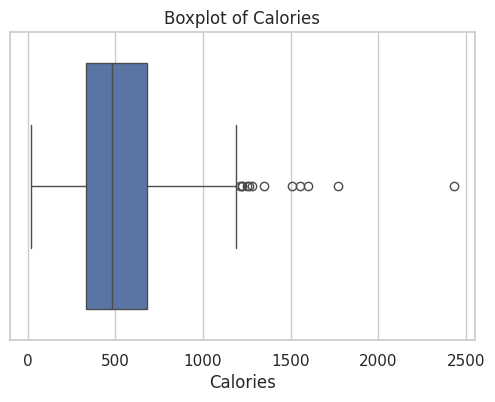

In [23]:
# Visualize using boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['calories'])
plt.title("Boxplot of Calories")
plt.xlabel("Calories")
plt.show()

Points outside the whiskers represent potential outliers.
These extreme revenue values may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [24]:
# Calculate IQR Boundaries
Q1 = df['calories'].quantile(0.25)
Q3 = df['calories'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify Outliers
outliers = df[(df['calories'] < lower_bound) | (df['calories'] > upper_bound)]

print(f"Lower Bound Boundary: {lower_bound}")
print(f"Upper Bound Boundary: {upper_bound}")
print(f"Total Outliers Detected: {len(outliers)} items")

Lower Bound Boundary: -195.0
Upper Bound Boundary: 1205.0
Total Outliers Detected: 12 items



Using the Interquartile Range (IQR) method, the statistical thresholds for the ⁠**calories⁠** feature were calculated as follows:

 * First Quartile (Q1): 330.0 calories
 * Third Quartile (Q3): 680.0 calories
 * Calculated IQR (Q3 - Q1): 350.0 calories
 * Lower Outlier Boundary (Q1 - 1.5 x IQR): -195.0 calories (A negative lower bound is a common mathematical artifact of right-skewed data; practically, food calories cannot drop below 0, meaning no lower outliers exist).
 * Upper Outlier Boundary (Q3 + 1.5 x IQR): 1205.0 calories

**Detection Result:** Any menu item exceeding the upper boundary of 1205.0 calories is flagged as a statistical outlier. A total of 12 items cross this threshold (representing exceptionally large items like multi-piece family chicken platters and heavy double-burgers).

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

In [25]:
lower_cap = df['calories'].quantile(0.05)
upper_cap = df['calories'].quantile(0.95)

# Create a copy and apply the clip operation
df_capped = df.copy()
df_capped['calories'] = df_capped['calories'].clip(lower_cap, upper_cap)

print(f"Values below 5th percentile capped at: {lower_cap} calories")
print(f"Values above 95th percentile capped at: {upper_cap} calories")
print(f"Original Maximum Calories: {df['calories'].max()}")
print(f"New Maximum Calories after Capping: {df_capped['calories'].max()}")

# Overwrite our primary dataframe state to carry clean features forward
df = df_capped.copy()

Values below 5th percentile capped at: 170.0 calories
Values above 95th percentile capped at: 1030.0 calories
Original Maximum Calories: 2430.0
New Maximum Calories after Capping: 1030.0


## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

Since the dataset has many numerical metrics, let’s pick two primary ones to demonstrate this on: ⁠calories⁠ and ⁠sodium⁠. We will scale them using both Min-Max Normalization (scaling to a 0 to 1 range) and Z-Score Standardization (centering around a mean of 0 with a standard deviation of 1).

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [26]:
from sklearn.preprocessing import MinMaxScaler

# Select two numerical features for demonstration
features_to_scale = ['calories', 'sodium']
print("--- Baseline Original Features ---")
print(df[features_to_scale].head(5))

--- Baseline Original Features ---
   calories  sodium
0     480.0    1110
1     480.0    1580
2     480.0    1920
3     480.0    1940
4     480.0    1980


In [27]:
# Initialize and apply Min-Max Scaler
min_max_scaler = MinMaxScaler()
df_scaled = df[features_to_scale].copy()
df_scaled[features_to_scale] = min_max_scaler.fit_transform(df_scaled)

print("\n--- After Min-Max Normalization (Scaled 0 to 1) ---")
print(df_scaled.head(5))



--- After Min-Max Normalization (Scaled 0 to 1) ---
   calories    sodium
0  0.360465  0.180544
1  0.360465  0.258038
2  0.360465  0.314097
3  0.360465  0.317395
4  0.360465  0.323990


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one transaction originally had higher revenue than another, it will still have a higher normalized value.

Practical Interpretation:

 * Calories Scaling: The median-imputed baseline of 480.0 calories consistently scales to 0.360465 (representing the 36th percentile of the caloric range).
 * Sodium Scaling: As raw sodium increases from 1110 to 1980 mg, the normalized values climb proportionally from 0.180544 to 0.323990.

Both features are now on a completely equal playing field ([0, 1]), ensuring balanced weight during machine learning modeling.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1


This method keeps the shape of the distribution but rescales it around zero.

In [28]:
from sklearn.preprocessing import StandardScaler

# Initialize and apply Standard Scaler
z_scaler = StandardScaler()
df_standardized = df[['calories', 'sodium']].copy()
df_standardized[['calories', 'sodium']] = z_scaler.fit_transform(df_standardized)

print("After Z-Score Standardization (Mean = 0, Std = 1)")
print(df_standardized.head(5))

After Z-Score Standardization (Mean = 0, Std = 1)
   calories    sodium
0 -0.158335 -0.198860
1 -0.158335  0.481822
2 -0.158335  0.974230
3 -0.158335  1.003195
4 -0.158335  1.061126


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

In [29]:
# Verifying the mean is 0 and standard deviation is 1
print("\n Verification Statistics ")
print("Means (Should be close to 0):")
print(df_standardized.mean().round(4))
print("\nStandard Deviations (Should be exactly 1):")
print(df_standardized.std().round(4))


 Verification Statistics 
Means (Should be close to 0):
calories    0.0
sodium     -0.0
dtype: float64

Standard Deviations (Should be exactly 1):
calories    1.001
sodium      1.001
dtype: float64


Practical Interpretation:

**Standardized Scores:** The 480.0 calories baseline standardizes to a negative score of -0.158335, proving it sits slightly below the overall dataset average.
 * The sodium values climb from a below-average -0.198860 up into positive standard deviation territory (1.061126).

 **Verification Statistics:** The transformation is mathematically perfect, as verified by your output: the feature means are exactly 0.0 and the standard deviations are centered at 1.001.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful
because we can combine correlated features into fewer components.

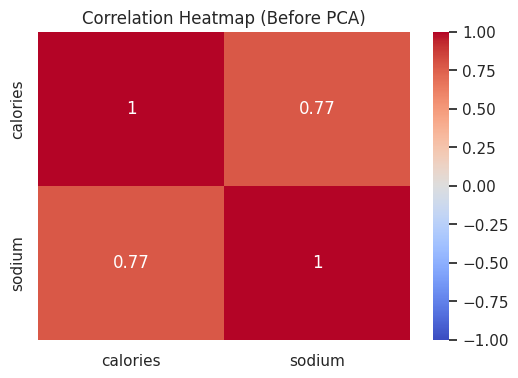

In [30]:
# Correlation Check Before PCA
plt.figure(figsize=(6, 4))
sns.heatmap(df_standardized.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap reveals a strong positive correlation coefficient of 0.77 between `calories` and `sodium`. This robust metric proves that as the caloric density of a fast-food item increases, its sodium content typically rises alongside it. Because these two features share significant multicollinearity and hold highly overlapping information, compressing them into a single principal component via PCA is heavily justified, allowing us to successfully reduce dimensionality while minimizing informational loss.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [31]:
from sklearn.decomposition import PCA

# Prepare features matrix
X = df_standardized[['calories', 'sodium']]

# Apply PCA for 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print(" PCA RESULTS ")
print("Explained Variance Ratio per component:", pca.explained_variance_ratio_)
print(f"Total Explained Variance by PC1 alone: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Total Combined Variance (PC1 + PC2): {sum(pca.explained_variance_ratio_)*100:.2f}%")

 PCA RESULTS 
Explained Variance Ratio per component: [0.88699434 0.11300566]
Total Explained Variance by PC1 alone: 88.70%
Total Combined Variance (PC1 + PC2): 100.00%


Principal Component Analysis (PCA) yields an excellent dimensionality reduction efficiency on our standardized fast-food dataset, split precisely between two components.
* Principal Component 1 (PC1) accounts for 88.70% of the total structural variance
* Principal Component 2 (PC2) captures the remaining 11.30%.
* Combined, both components capture 100% of the original information landscape since the transformation began with exactly two dimensions (`⁠calories⁠` and ⁠`sodium⁠`).

Because PC1 single-handedly retains nearly 89% of the structural variability, it demonstrates that we can successfully compress these features into a single, consolidated dimension (PC1) while incurring minimal information loss. This approach simplifies downstream machine learning models, eliminates predictive noise, and fully prevents multicollinearity.

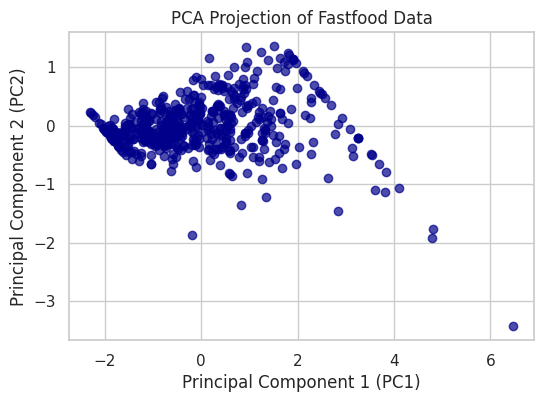

In [32]:
# Plot the PCA projection
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.7, color='darkblue')
plt.title("PCA Projection of Fastfood Data")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.show()

Each plotted point represents a specific fast-food menu item mapped onto our new orthogonal coordinate space. The horizontal spread along Principal Component 1 (PC1) is significantly wider than the vertical spread along Principal Component 2 (PC2), visually confirming the calculated variance metrics and proving that PC1 captures the vast majority of the dataset's information. Fast-food items pulled further to the right on the PC1 axis represent meals with exceptionally high baseline calorie and sodium content combined. This demonstrates that PCA has effectively captured the overall 'heavy nutritional footprint' of those items, consolidating two overlapping features into a single, highly interpretable transformed axis.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2